# PDE time series to generators with confidence

**Current surface:** V0.29.

## Purpose

Quickstart for the V0.29 surface: start from a canonical PDE time series, compute derivatives and residuals, fit a translation generator, verify it on held-out data, and read the confidence evidence.

## What you will learn

- How `FieldBatch`, `DerivativeBatch`, `ResidualBatch`, `GeneratorFamily`, and `VerificationReport` fit together.
- How metadata tags keep residual evaluators honest.
- How direct SVD evidence, fallback status, span distance, and verification errors should be read together.
- How the same pipeline covers Heat, Fisher-KPP reaction-diffusion, and the V0.19 advection-diffusion strong path.

## Required extras

Core install is enough for the code; Matplotlib is used only for optional tutorial plots and is included in `.[test]`.

## Expected runtime

About 1-2 minutes on a laptop.

## Out of scope

No new PDEs, no KS public API, no weak-form workflow, no train/test policy, and no claim that empirical verification is a mathematical proof.

These notebooks are tutorials, not API contracts. Example outputs are runtime summaries, not canonical paper artifacts.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from notebooks._tutorial_utils import (
    field_snapshot,
    plot_field_heatmap,
    plot_singular_values,
    plot_verification_curve,
    pretty_json,
    print_cards,
)
from pdelie.data import (
    generate_advection_diffusion_1d_field_batch,
    generate_heat_1d_field_batch,
    generate_reaction_diffusion_1d_field_batch,
    split_batch_train_heldout,
)
from pdelie.derivatives import compute_spectral_fd_derivatives
from pdelie.reporting import (
    summarize_generator_confidence,
    summarize_generator_fit_diagnostics,
    summarize_residual_batch,
    summarize_verification_report,
    summarize_vertical_slice,
)
from pdelie.residuals import (
    AdvectionDiffusionResidualEvaluator,
    HeatResidualEvaluator,
    ReactionDiffusionResidualEvaluator,
)
from pdelie.symmetry import fit_translation_generator
from pdelie.verification import verify_translation_generator

CONFIG = {
    "fit_epsilon": 1e-4,
    "verification_epsilons": None,
    "span_tolerance": 5e-2,
    "heat_seed_train": 100,
    "heat_seed_heldout": 101,
    "reaction_diffusion_seed": 18018,
    "reaction_diffusion_split_seed": 18019,
    "advection_diffusion_seed": 19019,
    "advection_diffusion_split_seed": 19020,
}
CONFIG

{'fit_epsilon': 0.0001,
 'verification_epsilons': None,
 'span_tolerance': 0.05,
 'heat_seed_train': 100,
 'heat_seed_heldout': 101,
 'reaction_diffusion_seed': 18018,
 'reaction_diffusion_split_seed': 18019,
 'advection_diffusion_seed': 19019,
 'advection_diffusion_split_seed': 19020}

## 1. Canonical fields are the common currency

`FieldBatch` is the object that lets data generation, residual evaluation, fitting, verification, and downstream helpers agree on axes, coordinates, variables, metadata, and provenance.


{
  "dims": [
    "batch",
    "time",
    "x",
    "var"
  ],
  "mask_present": false,
  "metadata_parameter_tags": {
    "nu": 0.1
  },
  "preprocess_steps": 0,
  "shape": [
    4,
    33,
    64,
    1
  ],
  "time_points": 33,
  "var_names": [
    "u"
  ],
  "x_points": 64
}


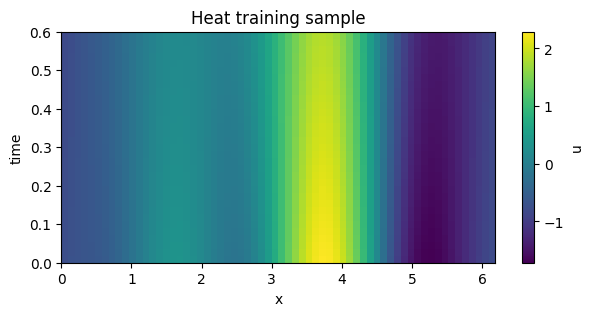

In [2]:
heat_train = generate_heat_1d_field_batch(batch_size=4, num_times=33, num_points=64, seed=CONFIG["heat_seed_train"])
heat_heldout = generate_heat_1d_field_batch(batch_size=3, num_times=33, num_points=64, seed=CONFIG["heat_seed_heldout"])

print(pretty_json(field_snapshot(heat_train), max_chars=2000))
plot_field_heatmap(heat_train, title="Heat training sample")

## 2. Residuals define the scientific target

PDELie does not fit symmetries in a vacuum. A generator is meaningful only relative to the residual it preserves.


In [3]:
heat_derivatives = compute_spectral_fd_derivatives(heat_train)
heat_evaluator = HeatResidualEvaluator()
heat_residual = heat_evaluator.evaluate(heat_train, heat_derivatives)
heat_residual_summary = summarize_residual_batch(heat_residual)
heat_residual_summary


{'summary_schema_version': '0.1',
 'summary_type': 'residual_batch',
 'residual_shape': [4, 33, 64, 1],
 'definition_type': 'analytic',
 'normalization': 'none',
 'max_abs_residual': 5.0258378954559646e-05,
 'rms_residual': 1.0771339104663567e-05,
 'diagnostics': {'backend': 'spectral_fd',
  'nu': 0.1,
  'max_abs_residual': 5.0258378954559646e-05}}

## 3. Fit, verify, then inspect the confidence card

The fitted object is a `GeneratorFamily`. The confidence card summarizes residual health, fit conditioning, span evidence, and held-out finite-transform verification.


[
  {
    "confidence_label": "strong",
    "fit_status": "passed",
    "label": "heat fitted translation",
    "residual_status": "passed",
    "verification_status": "passed"
  }
]
{
  "nested_sections": [
    "residual",
    "generator",
    "verification"
  ],
  "vertical_slice_summary_type": "vertical_slice"
}


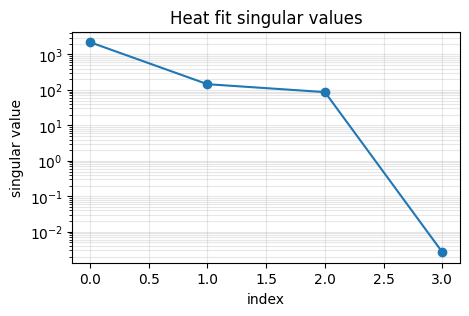

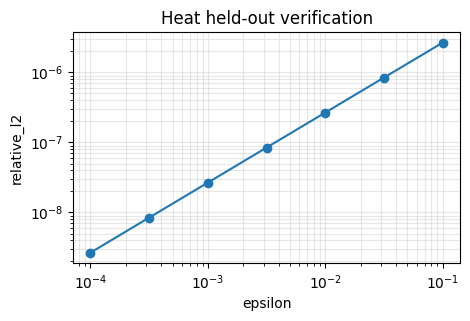

In [4]:
heat_generator = fit_translation_generator(
    heat_train,
    heat_evaluator,
    epsilon=CONFIG["fit_epsilon"],
)
heat_verification = verify_translation_generator(
    heat_heldout,
    heat_generator,
    heat_evaluator,
    epsilon_values=CONFIG["verification_epsilons"],
    span_tolerance=CONFIG["span_tolerance"],
)

heat_fit_summary = summarize_generator_fit_diagnostics(heat_generator)
heat_verification_summary = summarize_verification_report(heat_verification)
heat_vertical_slice = summarize_vertical_slice(
    derivatives=heat_derivatives,
    residual=heat_residual,
    generator=heat_generator,
    verification=heat_verification,
    extra_metrics={"case": "heat_quickstart"},
)
heat_confidence = summarize_generator_confidence(
    residual=heat_residual,
    generator=heat_generator,
    verification=heat_verification,
    thresholds={
        "residual_max_abs": 1e-3,
        "residual_rms": 1e-4,
        "verification_first_error": 1e-5,
        "verification_max_error": 1e-4,
    },
    extra_metrics={"label": "heat fitted translation"},
)
heat_card = {
    "label": "heat fitted translation",
    "confidence_label": heat_confidence["confidence_label"],
    "residual_status": heat_confidence["component_statuses"]["residual"]["status"],
    "fit_status": heat_confidence["component_statuses"]["fit"]["status"],
    "verification_status": heat_confidence["component_statuses"]["verification"]["status"],
}
print_cards([heat_card])
print(pretty_json({
    "vertical_slice_summary_type": heat_vertical_slice["summary_type"],
    "nested_sections": ["residual", "generator", "verification"],
}, max_chars=1500))
plot_singular_values(heat_fit_summary, title="Heat fit singular values")
plot_verification_curve(heat_verification_summary, title="Heat held-out verification")

## 4. Same workflow, Fisher-KPP and advection-diffusion

V0.18 added the scalar 1D periodic Fisher-KPP reaction-diffusion path. V0.19 added a similarly scoped constant-coefficient advection-diffusion path. They are good tutorial contrasts: one reacts and diffuses; the other advects like a smoke line while diffusion smooths it. Both stay inside the same strong-form scalar 1D periodic pipeline.

[
  {
    "confidence_label": "strong",
    "fit_status": "passed",
    "label": "heat fitted translation",
    "residual_status": "passed",
    "verification_status": "passed"
  },
  {
    "confidence_label": "strong",
    "equation_tag": "reaction_diffusion_fisher_kpp",
    "fallback": false,
    "fit_evidence": "direct_svd_in_tolerance",
    "label": "Fisher-KPP fitted translation",
    "verification": "exact"
  },
  {
    "confidence_label": "strong",
    "equation_tag": "advection_diffusion_constant_coefficient",
    "fallback": false,
    "fit_evidence": "direct_svd_in_tolerance",
    "label": "advection-diffusion fitted translation",
    "verification": "exact"
  }
]


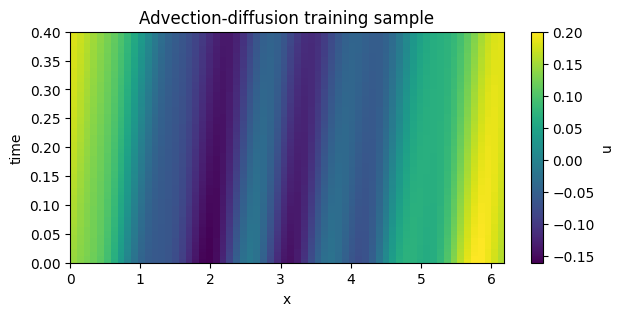

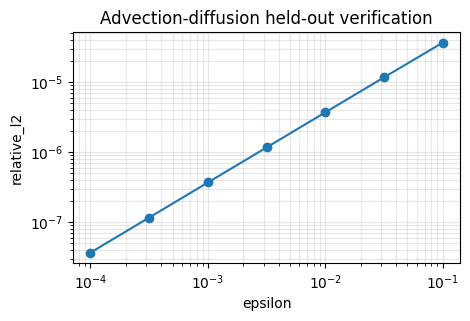

In [5]:
rd_field = generate_reaction_diffusion_1d_field_batch(batch_size=5, seed=CONFIG["reaction_diffusion_seed"])
rd_train, rd_heldout = split_batch_train_heldout(
    rd_field,
    train_size=2,
    seed=CONFIG["reaction_diffusion_split_seed"],
)
rd_evaluator = ReactionDiffusionResidualEvaluator()
rd_derivatives = compute_spectral_fd_derivatives(rd_train)
rd_residual = rd_evaluator.evaluate(rd_train, rd_derivatives)
rd_generator = fit_translation_generator(rd_train, rd_evaluator, epsilon=CONFIG["fit_epsilon"])
rd_verification = verify_translation_generator(rd_heldout, rd_generator, rd_evaluator)
rd_fit_summary = summarize_generator_fit_diagnostics(rd_generator)
rd_verification_summary = summarize_verification_report(rd_verification)
rd_confidence = summarize_generator_confidence(
    residual=rd_residual,
    generator=rd_generator,
    verification=rd_verification,
    thresholds={
        "residual_max_abs": 5e-4,
        "residual_rms": 5e-5,
        "verification_first_error": 5e-4,
        "verification_max_error": 5e-3,
    },
    extra_metrics={"label": "Fisher-KPP fitted translation"},
)

ad_field = generate_advection_diffusion_1d_field_batch(batch_size=5, seed=CONFIG["advection_diffusion_seed"])
ad_train, ad_heldout = split_batch_train_heldout(
    ad_field,
    train_size=2,
    seed=CONFIG["advection_diffusion_split_seed"],
)
ad_evaluator = AdvectionDiffusionResidualEvaluator()
ad_derivatives = compute_spectral_fd_derivatives(ad_train)
ad_residual = ad_evaluator.evaluate(ad_train, ad_derivatives)
ad_generator = fit_translation_generator(ad_train, ad_evaluator, epsilon=CONFIG["fit_epsilon"])
ad_verification = verify_translation_generator(ad_heldout, ad_generator, ad_evaluator)
ad_fit_summary = summarize_generator_fit_diagnostics(ad_generator)
ad_verification_summary = summarize_verification_report(ad_verification)
ad_confidence = summarize_generator_confidence(
    residual=ad_residual,
    generator=ad_generator,
    verification=ad_verification,
    thresholds={
        "residual_max_abs": 5e-4,
        "residual_rms": 5e-5,
        "verification_first_error": 5e-4,
        "verification_max_error": 5e-3,
    },
    extra_metrics={"label": "advection-diffusion fitted translation"},
)

cards = [
    heat_card,
    {
        "label": "Fisher-KPP fitted translation",
        "equation_tag": rd_train.metadata["parameter_tags"]["equation"],
        "confidence_label": rd_confidence["confidence_label"],
        "fit_evidence": rd_fit_summary["evidence_label"],
        "fallback": rd_fit_summary["reference_fallback_used"],
        "verification": rd_verification_summary["classification"],
    },
    {
        "label": "advection-diffusion fitted translation",
        "equation_tag": ad_train.metadata["parameter_tags"]["equation"],
        "confidence_label": ad_confidence["confidence_label"],
        "fit_evidence": ad_fit_summary["evidence_label"],
        "fallback": ad_fit_summary["reference_fallback_used"],
        "verification": ad_verification_summary["classification"],
    },
]
print_cards(cards)
plot_field_heatmap(ad_train, title="Advection-diffusion training sample")
plot_verification_curve(ad_verification_summary, title="Advection-diffusion held-out verification")

## Recap

You saw the core V0.29 flow: canonical field, derivatives, residual, fitted translation generator, held-out verification, and package-level confidence reporting across Heat, Fisher-KPP, and advection-diffusion.

## Common pitfalls

- Treating generator coefficients as enough evidence by themselves.
- Ignoring metadata tags; residual evaluators use them to reject the wrong equation family.
- Confusing empirical verification with a mathematical proof.
- Treating fallback-backed evidence as equivalent to direct SVD recovery.

## Extension ideas

- Swap Heat for Burgers, KdV, or Fisher-KPP and compare residual and fit diagnostics.
- Change `fit_epsilon` and inspect the condition number and span distance.
- Route the vertical-slice summary into a report table for your own experiment log.

## What to read/run next

Run `01_raw_vs_translation_canonical_discovery.ipynb` for downstream preprocessing, then `06_orbit_coverage_diagnostics.ipynb` for invariant/orbit reports.